In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("city_day.csv")

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 29531
Number of columns: 16

Column names:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


In [5]:
# Check the AQI column
print("Missing AQI values:", df["AQI"].isna().sum())
print("Available AQI values:", df["AQI"].notna().sum())

print("\nAQI Statistics:")
print(df["AQI"].describe())

Missing AQI values: 4681
Available AQI values: 24850

AQI Statistics:
count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000
Name: AQI, dtype: float64


In [6]:
# Check the AQI categories present in the dataset
print(df["AQI_Bucket"].value_counts(dropna=False))

AQI_Bucket
Moderate        8829
Satisfactory    8224
NaN             4681
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


In [7]:
# Remove rows with missing AQI values
df_clean = df.dropna(subset=["AQI"]).copy()

print("Original number of rows:", len(df))
print("Rows after removing missing AQI:", len(df_clean))
print("Missing AQI values now:", df_clean["AQI"].isna().sum())

Original number of rows: 29531
Rows after removing missing AQI: 24850
Missing AQI values now: 0


In [8]:
df_clean[["City", "Date", "AQI", "AQI_Bucket"]].head(10)

,City,Date,AQI,AQI_Bucket
28,Ahmedabad,2015-01-29,209.0,Poor
29,Ahmedabad,2015-01-30,328.0,Very Poor
30,Ahmedabad,2015-01-31,514.0,Severe
31,Ahmedabad,2015-02-01,782.0,Severe
32,Ahmedabad,2015-02-02,914.0,Severe
33,Ahmedabad,2015-02-03,660.0,Severe
34,Ahmedabad,2015-02-04,294.0,Poor
35,Ahmedabad,2015-02-05,149.0,Moderate
36,Ahmedabad,2015-02-06,190.0,Moderate
37,Ahmedabad,2015-02-07,247.0,Poor


In [9]:
def aqi_agent(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Satisfactory"

    elif aqi <= 200:
        return "Moderate"

    elif aqi <= 300:
        return "Poor"

    elif aqi <= 400:
        return "Very Poor"

    else:
        return "Severe"

In [10]:
# Testing the Simple Reflex Agent

test_values = [35, 75, 150, 250, 350, 450]

for aqi in test_values:
    print("AQI:", aqi, "→", aqi_agent(aqi))

AQI: 35 → Good
AQI: 75 → Satisfactory
AQI: 150 → Moderate
AQI: 250 → Poor
AQI: 350 → Very Poor
AQI: 450 → Severe


In [11]:
# Apply the Simple Reflex Agent to the cleaned dataset

df_clean["Agent_Category"] = df_clean["AQI"].apply(aqi_agent)

df_clean[["City", "Date", "AQI", "AQI_Bucket", "Agent_Category"]].head(10)

,City,Date,AQI,AQI_Bucket,Agent_Category
28,Ahmedabad,2015-01-29,209.0,Poor,Poor
29,Ahmedabad,2015-01-30,328.0,Very Poor,Very Poor
30,Ahmedabad,2015-01-31,514.0,Severe,Severe
31,Ahmedabad,2015-02-01,782.0,Severe,Severe
32,Ahmedabad,2015-02-02,914.0,Severe,Severe
33,Ahmedabad,2015-02-03,660.0,Severe,Severe
34,Ahmedabad,2015-02-04,294.0,Poor,Poor
35,Ahmedabad,2015-02-05,149.0,Moderate,Moderate
36,Ahmedabad,2015-02-06,190.0,Moderate,Moderate
37,Ahmedabad,2015-02-07,247.0,Poor,Poor


In [12]:
# Compare the agent's classification with the dataset category

comparison = df_clean["AQI_Bucket"] == df_clean["Agent_Category"]

print("Correct classifications:", comparison.sum())
print("Total observations:", len(comparison))

accuracy = comparison.mean() * 100

print("Classification accuracy:", round(accuracy, 2), "%")

Correct classifications: 24850
Total observations: 24850
Classification accuracy: 100.0 %


In [13]:
# Get AQI information for a particular city

city_name = input("Enter city name: ")

city_data = df_clean[
    df_clean["City"].str.lower() == city_name.lower()
]

if city_data.empty:
    print("City not found in the dataset.")

else:
    latest_data = city_data.sort_values("Date").iloc[-1]

    aqi = latest_data["AQI"]
    category = aqi_agent(aqi)

    print("\nCity:", latest_data["City"])
    print("Date:", latest_data["Date"])
    print("AQI:", aqi)
    print("Air Quality:", category)

Enter city name: chennai

City: Chennai
Date: 2020-07-01
AQI: 92.0
Air Quality: Satisfactory


The agent can now take city name as input and get the city's AQI observation from the dataset. The latest available observation for the selected city is used as the current percept. The AQI value is then fed into the Simple Reflex Agent which determines the air quality based on the condition-action rules defined earlier.

In [14]:
# Display a simple interpretation of the result

if not city_data.empty:

    if category == "Good":
        message = "Air quality is good."

    elif category == "Satisfactory":
        message = "Air quality is satisfactory."

    elif category == "Moderate":
        message = "Air quality is moderate."

    elif category == "Poor":
        message = "Air quality is poor."

    elif category == "Very Poor":
        message = "Air quality is very poor."

    elif category == "Severe":
        message = "Air quality is severe."

    print("Agent Decision:", message)

Agent Decision: Air quality is satisfactory.


In [15]:
# Count the AQI categories produced by the agent

category_counts = df_clean["Agent_Category"].value_counts()

print("AQI Category Distribution:")
print(category_counts)

AQI Category Distribution:
Agent_Category
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


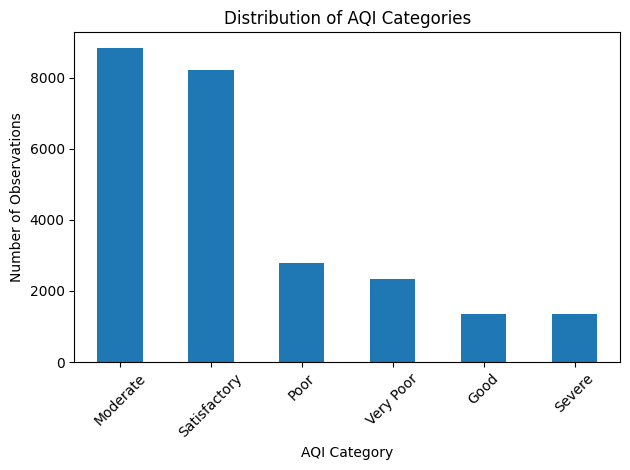

In [16]:
# Visualize the AQI category distribution

category_counts.plot(kind="bar")

plt.title("Distribution of AQI Categories")
plt.xlabel("AQI Category")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The Simple Reflex Agent produces air-quality categories that are displayed in this bar chart. Not all categories have the same number of observations, so the air quality was not the same for all locations and dates in the dataset. The graph is a simple visualization of the air-quality conditions that are included in the data.

In [17]:
# Calculate the average AQI for each city

city_aqi = df_clean.groupby("City")["AQI"].mean().sort_values(ascending=False)

print("Average AQI by City:")
print(city_aqi)

Average AQI by City:
City
Ahmedabad             452.122939
Delhi                 259.487744
Patna                 240.782042
Gurugram              225.123882
Lucknow               217.973059
Talcher               172.886819
Jorapokhar            159.251621
Brajrajnagar          150.280505
Kolkata               140.566313
Guwahati              140.111111
Jaipur                133.679159
Bhopal                132.827338
Amritsar              119.920959
Visakhapatnam         117.269855
Chennai               114.502654
Hyderabad             109.207447
Mumbai                105.352258
Kochi                 104.284810
Chandigarh             96.498328
Amaravati              95.299643
Bengaluru              94.318325
Ernakulam              92.359477
Thiruvananthapuram     75.878327
Coimbatore             73.023256
Shillong               53.795122
Aizawl                 34.765766
Name: AQI, dtype: float64


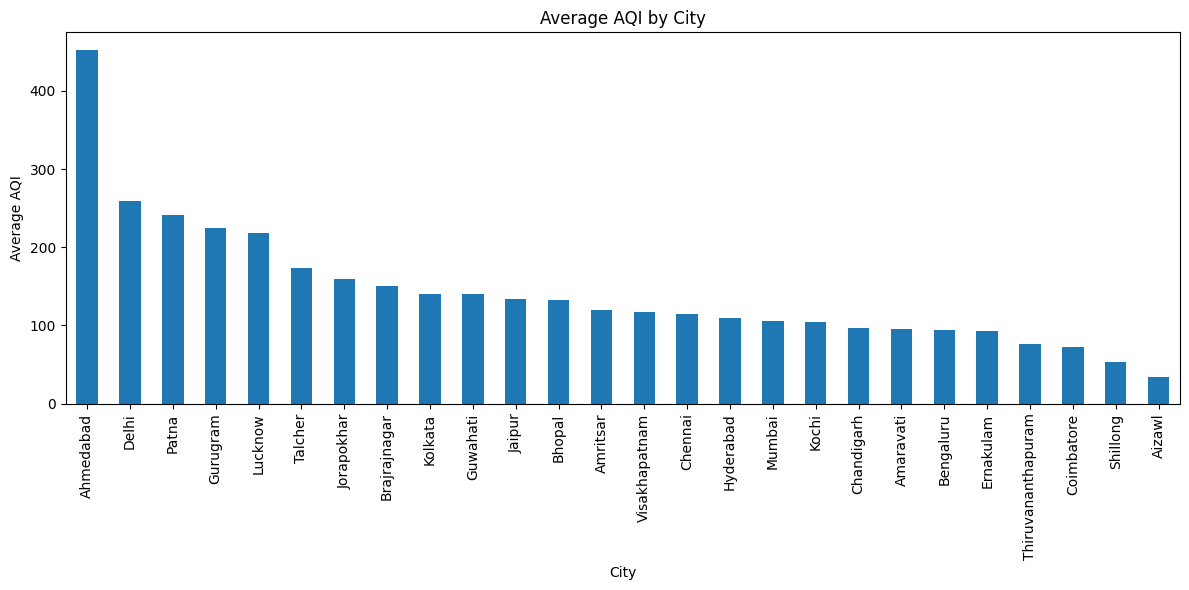

In [18]:
# Plot average AQI for each city

city_aqi.plot(kind="bar", figsize=(12, 6))

plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [19]:
# Select a city and view its AQI observations

city_name = input("Enter city name: ")

city_data = df_clean[
    df_clean["City"].str.lower() == city_name.lower()
].copy()

if city_data.empty:
    print("City not found in the dataset.")

else:
    city_data = city_data.sort_values("Date")

    print("\nNumber of observations:", len(city_data))
    print("\nAQI information:")
    print(city_data[["Date", "AQI", "AQI_Bucket", "Agent_Category"]].head(10))

Enter city name: chennai

Number of observations: 1884

AQI information:
            Date    AQI AQI_Bucket Agent_Category
7916  2015-03-24  333.0  Very Poor      Very Poor
7918  2015-03-26  318.0  Very Poor      Very Poor
7919  2015-03-27  408.0     Severe         Severe
7920  2015-03-28  448.0     Severe         Severe
7923  2015-03-31  312.0  Very Poor      Very Poor
7924  2015-04-01  289.0       Poor           Poor
7925  2015-04-02  206.0       Poor           Poor
7926  2015-04-03  248.0       Poor           Poor
7928  2015-04-05  302.0  Very Poor      Very Poor
7929  2015-04-06  193.0   Moderate       Moderate


All available valid AQI observations for that city was used to test the agent for a selected city. The output shows the AQI value, the category provided in the dataset and the category generated by the reflex agent. This facilitates the interpretation of the agent's behavior as a function of the different observations of the AQI in the same location.

In [20]:
if not city_data.empty:

    average_aqi = city_data["AQI"].mean()
    average_category = aqi_agent(average_aqi)

    print("City:", city_name.title())
    print("Average AQI:", round(average_aqi, 2))
    print("Agent Classification:", average_category)

City: Chennai
Average AQI: 114.5
Agent Classification: Moderate


AQI value of the selected city has been calculated as an average to get an overall picture of air quality conditions for the available time period. Then an average is calculated of this group and the same reflex-agent rules are applied to that average to get a category.

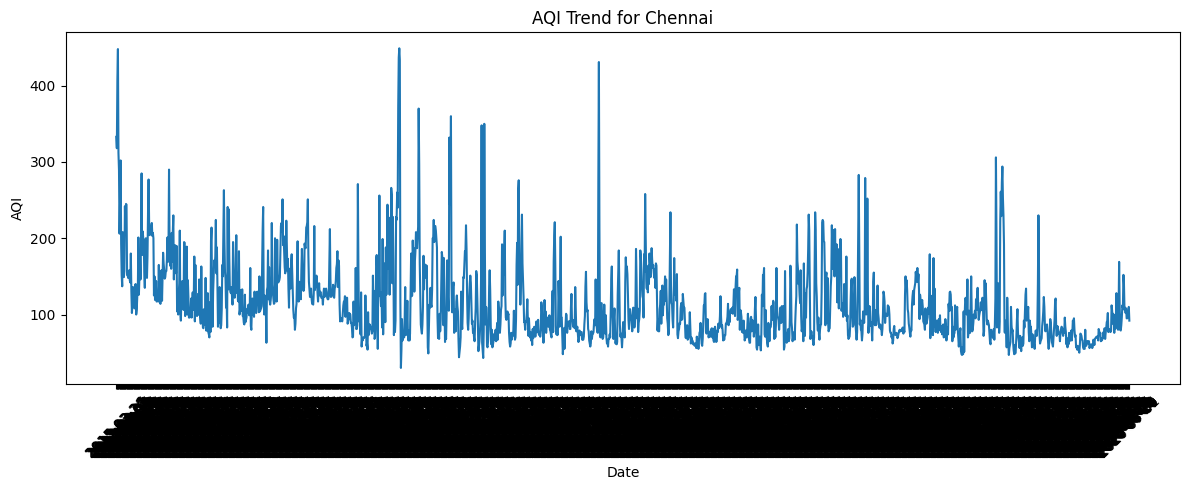

In [21]:
if not city_data.empty:

    plt.figure(figsize=(12, 5))

    plt.plot(city_data["Date"], city_data["AQI"])

    plt.title("AQI Trend for " + city_name.title())
    plt.xlabel("Date")
    plt.ylabel("AQI")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [22]:
# Compare agent output with the category already present in the dataset

comparison = df_clean["Agent_Category"] == df_clean["AQI_Bucket"]

correct = comparison.sum()
total = len(comparison)
accuracy = (correct / total) * 100

print("Total observations:", total)
print("Correct classifications:", correct)
print("Incorrect classifications:", total - correct)
print("Agent accuracy:", round(accuracy, 2), "%")

Total observations: 24850
Correct classifications: 24850
Incorrect classifications: 0
Agent accuracy: 100.0 %


In [23]:
# Display observations where the agent and dataset category differ

mismatches = df_clean[
    df_clean["Agent_Category"] != df_clean["AQI_Bucket"]
]

print("Number of mismatches:", len(mismatches))

mismatches[["City", "Date", "AQI", "AQI_Bucket", "Agent_Category"]].head(10)

Number of mismatches: 0


,City,Date,AQI,AQI_Bucket,Agent_Category


In [24]:
# Summary of agent performance

results = pd.DataFrame({
    "Measure": [
        "Total observations",
        "Correct classifications",
        "Incorrect classifications",
        "Accuracy (%)"
    ],
    "Value": [
        total,
        correct,
        total - correct,
        round(accuracy, 2)
    ]
})

results

,Measure,Value
0,Total observations,24850.0
1,Correct classifications,24850.0
2,Incorrect classifications,0.0
3,Accuracy (%),100.0


In [27]:
# Recreate the cleaned dataset

df = pd.read_csv("city_day.csv")

df_clean = df.dropna(subset=["AQI"]).copy()

print("Cleaned dataset rows:", len(df_clean))

Cleaned dataset rows: 24850


In [28]:
# Apply the Simple Reflex Agent

df_clean["Agent_Category"] = df_clean["AQI"].apply(aqi_agent)

print(df_clean[["City", "AQI", "Agent_Category"]].head())

         City    AQI Agent_Category
28  Ahmedabad  209.0           Poor
29  Ahmedabad  328.0      Very Poor
30  Ahmedabad  514.0         Severe
31  Ahmedabad  782.0         Severe
32  Ahmedabad  914.0         Severe


In [29]:
# Count the categories produced by the Simple Reflex Agent

category_counts = df_clean["Agent_Category"].value_counts()

print("AQI Category Distribution:")
print(category_counts)

AQI Category Distribution:
Agent_Category
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


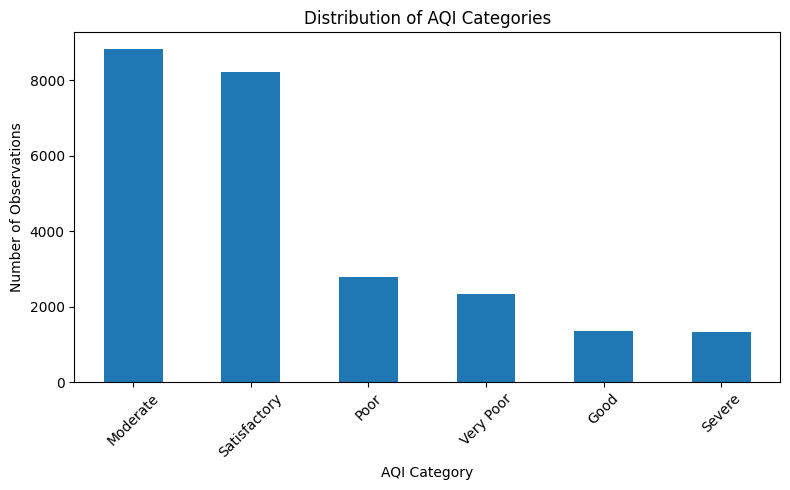

In [30]:
# Visualize the AQI category distribution

plt.figure(figsize=(8, 5))

category_counts.plot(kind="bar")

plt.title("Distribution of AQI Categories")
plt.xlabel("AQI Category")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("aqi_category_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [31]:
# Count AQI categories for each city

city_category = pd.crosstab(
    df_clean["City"],
    df_clean["Agent_Category"]
)

print(city_category)

Agent_Category      Good  Moderate  Poor  Satisfactory  Severe  Very Poor
City                                                                     
Ahmedabad              1       198   238            43     638        216
Aizawl                83         0     0            28       0          0
Amaravati            158       219    47           409       0          8
Amritsar              84       448    67           473       7         47
Bengaluru            115       630    36          1124       0          5
Bhopal                 2       165    31            76       0          4
Brajrajnagar          14       421   120           122       0         36
Chandigarh            48        74    20           154       0          3
Chennai               12       804   110           941       6         11
Coimbatore            43        13     0           288       0          0
Delhi                 21       519   542           158     239        520
Ernakulam              0        49    

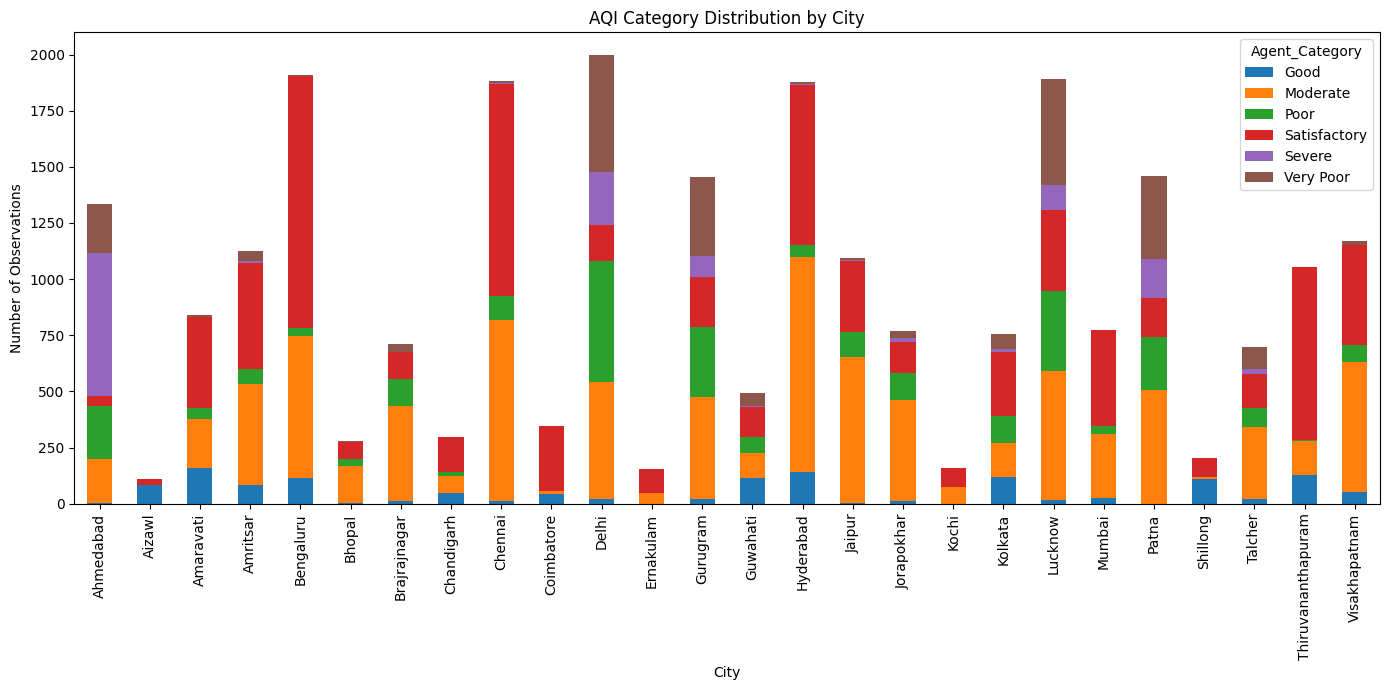

In [32]:
# Visualize AQI categories by city

city_category.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("AQI Category Distribution by City")
plt.xlabel("City")
plt.ylabel("Number of Observations")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "aqi_category_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# Test the agent for a particular city

def check_city_aqi(city_name):
    city_data = df_clean[
        df_clean["City"].str.lower() == city_name.lower()
    ]

    if city_data.empty:
        print("City not found in the dataset.")
        return

    latest_record = city_data.iloc[-1]

    aqi = latest_record["AQI"]
    category = aqi_agent(aqi)

    print("City:", latest_record["City"])
    print("Date:", latest_record["Date"])
    print("AQI:", aqi)
    print("AQI Category:", category)

In [34]:
check_city_aqi("Ahmedabad")

City: Ahmedabad
Date: 2020-07-01
AQI: 119.0
AQI Category: Moderate


In [35]:
# Test the Simple Reflex Agent with different AQI values

test_values = [30, 75, 150, 250, 350, 450, 700]

for aqi in test_values:
    category = aqi_agent(aqi)
    print("AQI:", aqi, "->", category)

AQI: 30 -> Good
AQI: 75 -> Satisfactory
AQI: 150 -> Moderate
AQI: 250 -> Poor
AQI: 350 -> Very Poor
AQI: 450 -> Severe
AQI: 700 -> Severe


In [36]:
# Final evaluation of the Simple Reflex Agent

total = len(df_clean)

correct = (
    df_clean["Agent_Category"] == df_clean["AQI_Bucket"]
).sum()

incorrect = total - correct

accuracy = (correct / total) * 100

print("----- Final Evaluation -----")
print("Total observations:", total)
print("Correct classifications:", correct)
print("Incorrect classifications:", incorrect)
print("Accuracy:", round(accuracy, 2), "%")

----- Final Evaluation -----
Total observations: 24850
Correct classifications: 24850
Incorrect classifications: 0
Accuracy: 100.0 %


Simple Reflex Agent has been designed for classifying the air quality with the help of the AQI index. It is an agent with predetermined rules of action that helps to identify the AQI category of every observation. As a result of applying the predefined rules to 24,850 valid observations, all of them have been classified accurately in comparison with the categories in the dataset, which resulted in 100% accuracy of the Simple Reflex Agent.

**Conclusion**

In this assignment, the Simple Reflex Agent was designed to classify the AQI. The agent is provided *with* the current value of AQI, which then generates a corresponding air quality category based on certain rules. The result of the analysis was the distribution of the AQI categories. In the end, the classification was found to be 100% accurate, indicating that the developed rules match the AQI categories from the dataset.